# 03e. Hyperparameter Tuning — Rescue Config C

**Project:** KPI-RAG: Explainable Root-Cause Analysis for 5G Networks
**Stage:** Phase 1 — Advanced Tuning

## Purpose

Notebooks 03, 03b, 03c, 03d all showed Config A (64-dim) outperforming Config C (582-dim).
Root cause: 988 samples / 582 features = 1.7 samples per feature (curse of dimensionality).

This notebook applies aggressive regularization via hyperparameter tuning specifically
targeting Config C. The key hypothesis:

**If `max_features='sqrt'` is used, each tree sees only sqrt(582) = 24 features,
which respects the samples-per-feature rule internally and may recover Config C performance.**

## What Changes vs Previous Notebooks

Previous notebooks used default RF parameters:
- max_features = 'sqrt' (default already)
- max_depth = None
- min_samples_leaf = 2

This notebook systematically tunes:
- max_features: aggressive feature subsampling
- max_depth: tree complexity control
- min_samples_leaf: leaf regularization
- min_samples_split: split regularization

Using RandomizedSearchCV with 30 iterations x 3-fold CV = 90 model fits per algorithm.

## Non-destructive

This notebook does not modify any previous results or saved arrays.
If tuning fails, previous conclusions stand. If it succeeds, we update the decision.

## 1. Imports and Configuration

In [5]:
import numpy as np
import pandas as pd
import os
import json
import time
import warnings
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, precision_score, recall_score, make_scorer
from scipy.stats import randint, uniform

warnings.filterwarnings('ignore')

COLORS = {
    'normal':     '#2E6DB4',
    'anomaly':    '#C0392B',
    'jamming':    '#E67E22',
    'synthetic':  '#85929E',
    'axis':       '#2C3E50',
    'grid':       '#F2F4F6',
}

DATA_DIR = r'C:\Users\DELL\Desktop\kpi_rag\data'

X_full       = np.load(os.path.join(DATA_DIR, 'X_features.npy'))
y_binary     = np.load(os.path.join(DATA_DIR, 'y_binary.npy'))
y_multiclass = np.load(os.path.join(DATA_DIR, 'y_multiclass.npy'))
train_idx    = np.load(os.path.join(DATA_DIR, 'train_idx.npy'))
test_idx     = np.load(os.path.join(DATA_DIR, 'test_idx.npy'))

with open(os.path.join(DATA_DIR, 'type_to_int.json')) as f:
    type_to_int = json.load(f)

X_A = X_full[:, :64]
X_C = X_full[:, :582]

X_A_train, X_A_test = X_A[train_idx], X_A[test_idx]
X_C_train, X_C_test = X_C[train_idx], X_C[test_idx]

y_bin_train = y_binary[train_idx]
y_bin_test  = y_binary[test_idx]
y_mc_train  = y_multiclass[train_idx]
y_mc_test   = y_multiclass[test_idx]

print(f'Config A: {X_A.shape}')
print(f'Config C: {X_C.shape}')
print(f'Train: {len(train_idx):,}   Test: {len(test_idx):,}')

Config A: (32000, 64)
Config C: (32000, 582)
Train: 25,600   Test: 6,400


## 2. Baseline Reference

Reference values from previous notebooks — untuned models.

In [6]:
BASELINE = {
    'A_binary_untuned': 0.9835,
    'C_binary_untuned': 0.9665,
    'A_fault_untuned':  0.9447,
    'C_fault_untuned':  0.8872,
    'best_binary_ever': 0.9856,
    'best_fault_ever':  0.9564,
}

print('Baseline (Untuned) Results:')
print(f'  Config A Binary: {BASELINE["A_binary_untuned"]:.4f}')
print(f'  Config C Binary: {BASELINE["C_binary_untuned"]:.4f}')
print(f'  Config A Fault:  {BASELINE["A_fault_untuned"]:.4f}')
print(f'  Config C Fault:  {BASELINE["C_fault_untuned"]:.4f}')
print()
print(f'Best ever (across all notebooks):')
print(f'  Binary: {BASELINE["best_binary_ever"]:.4f}')
print(f'  Fault:  {BASELINE["best_fault_ever"]:.4f}')

Baseline (Untuned) Results:
  Config A Binary: 0.9835
  Config C Binary: 0.9665
  Config A Fault:  0.9447
  Config C Fault:  0.8872

Best ever (across all notebooks):
  Binary: 0.9856
  Fault:  0.9564


## 3. Parameter Search Space — Regularization-Focused

The search space is designed to counteract the curse of dimensionality:

- `max_features`: aggressive subsampling. 'sqrt' means each tree sees ~24 of 582 features.
- `min_samples_leaf`: high values force each leaf to represent many samples.
- `min_samples_split`: prevents splits with too few samples.
- `max_depth`: caps tree complexity.

In [7]:
param_dist = {
    'max_features':      ['sqrt', 'log2'],
    'max_depth':         [8, 12],
    'min_samples_leaf':  randint(5, 20),
    'min_samples_split': randint(10, 30),
    'n_estimators':      [200],
    'class_weight':      ['balanced'],
    'random_state':      [42],
    'n_jobs':            [1],
}
print('Parameter search space defined.')
print(f'max_features options: {param_dist["max_features"]}')
print(f'max_depth options:    {param_dist["max_depth"]}')

Parameter search space defined.
max_features options: ['sqrt', 'log2']
max_depth options:    [8, 12]


## 4. Tune Config C — Binary Anomaly Detector

30 random parameter combinations x 3-fold CV = 90 model fits.
This may take 10-20 minutes.

In [8]:
print('Tuning Config C — Binary Anomaly Detector')
print('=' * 50)

t0 = time.time()

search_C_binary = RandomizedSearchCV(
    estimator=RandomForestClassifier(),
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=2,
    random_state=42,
    verbose=1,
)

search_C_binary.fit(X_C_train, y_bin_train)

elapsed = time.time() - t0
print(f'\nSearch complete in {elapsed/60:.1f} minutes.')
print(f'Best CV F1: {search_C_binary.best_score_:.4f}')
print(f'Best params:')
for k, v in search_C_binary.best_params_.items():
    print(f'  {k}: {v}')

Tuning Config C — Binary Anomaly Detector
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Search complete in 4.7 minutes.
Best CV F1: 0.9383
Best params:
  class_weight: balanced
  max_depth: 12
  max_features: sqrt
  min_samples_leaf: 11
  min_samples_split: 20
  n_estimators: 200
  n_jobs: 1
  random_state: 42


## 5. Evaluate Tuned Config C — Binary Detection

In [9]:
best_C_binary = search_C_binary.best_estimator_
y_pred = best_C_binary.predict(X_C_test)

tuned_C_binary_f1 = f1_score(y_bin_test, y_pred, pos_label=1)
tuned_C_binary_p  = precision_score(y_bin_test, y_pred, pos_label=1, zero_division=0)
tuned_C_binary_r  = recall_score(y_bin_test, y_pred, pos_label=1, zero_division=0)

print('Config C Binary — Tuned Results:')
print(f'  F1:        {tuned_C_binary_f1:.4f}')
print(f'  Precision: {tuned_C_binary_p:.4f}')
print(f'  Recall:    {tuned_C_binary_r:.4f}')
print()
print('Comparison:')
print(f'  Config C untuned:   {BASELINE["C_binary_untuned"]:.4f}')
print(f'  Config C tuned:     {tuned_C_binary_f1:.4f}')
print(f'  Improvement:        {tuned_C_binary_f1 - BASELINE["C_binary_untuned"]:+.4f}')
print()
print(f'  Config A untuned:   {BASELINE["A_binary_untuned"]:.4f}')
print(f'  Best ever binary:   {BASELINE["best_binary_ever"]:.4f}')
if tuned_C_binary_f1 > BASELINE["best_binary_ever"]:
    print(f'  Tuned C beats best ever: YES (+{tuned_C_binary_f1 - BASELINE["best_binary_ever"]:.4f})')
elif tuned_C_binary_f1 > BASELINE["A_binary_untuned"]:
    print(f'  Tuned C beats untuned A: YES (+{tuned_C_binary_f1 - BASELINE["A_binary_untuned"]:.4f})')
else:
    print(f'  Tuned C beats untuned A: NO')

Config C Binary — Tuned Results:
  F1:        0.9549
  Precision: 0.9668
  Recall:    0.9433

Comparison:
  Config C untuned:   0.9665
  Config C tuned:     0.9549
  Improvement:        -0.0116

  Config A untuned:   0.9835
  Best ever binary:   0.9856
  Tuned C beats untuned A: NO


## 6. Tune Config C — Fault Classifier

Same approach applied to the fault classification task.
Jamming excluded from training (held-out generalization probe).

In [10]:
jamming_class = type_to_int.get('Jamming', -1)

mask_tr = (y_mc_train > 0) & (y_mc_train != jamming_class)
mask_te = (y_mc_test  > 0) & (y_mc_test  != jamming_class)

X_C_tr_mc = X_C_train[mask_tr]
y_mc_tr   = y_mc_train[mask_tr]
X_C_te_mc = X_C_test[mask_te]
y_mc_te   = y_mc_test[mask_te]

unique = np.sort(np.unique(y_mc_tr))
c2i = {c: i for i, c in enumerate(unique)}
y_mc_tr_m = np.array([c2i[c] for c in y_mc_tr])
y_mc_te_m = np.array([c2i.get(c, -1) for c in y_mc_te])
valid = y_mc_te_m >= 0
X_C_te_mc = X_C_te_mc[valid]
y_mc_te_m = y_mc_te_m[valid]

print('Tuning Config C — Fault Classifier')
print('=' * 50)
print(f'Training samples (Jamming excluded): {len(X_C_tr_mc):,}')
print(f'Classes: {len(unique)}')

t0 = time.time()

search_C_mc = RandomizedSearchCV(
    estimator=RandomForestClassifier(),
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=1,
    random_state=42,
    verbose=1,
)

search_C_mc.fit(X_C_tr_mc, y_mc_tr_m)

elapsed = time.time() - t0
print(f'\nSearch complete in {elapsed/60:.1f} minutes.')
print(f'Best CV F1-macro: {search_C_mc.best_score_:.4f}')
print(f'Best params:')
for k, v in search_C_mc.best_params_.items():
    print(f'  {k}: {v}')

Tuning Config C — Fault Classifier
Training samples (Jamming excluded): 765
Classes: 10
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Search complete in 0.4 minutes.
Best CV F1-macro: 0.7477
Best params:
  class_weight: balanced
  max_depth: 12
  max_features: log2
  min_samples_leaf: 7
  min_samples_split: 11
  n_estimators: 200
  n_jobs: 1
  random_state: 42


## 7. Evaluate Tuned Config C — Fault Classifier

In [11]:
best_C_mc = search_C_mc.best_estimator_
y_pred_mc = best_C_mc.predict(X_C_te_mc)

tuned_C_mc_f1  = f1_score(y_mc_te_m, y_pred_mc, average='macro', zero_division=0)
tuned_C_mc_acc = (y_pred_mc == y_mc_te_m).mean()

print('Config C Fault — Tuned Results:')
print(f'  F1-macro:  {tuned_C_mc_f1:.4f}')
print(f'  Accuracy:  {tuned_C_mc_acc:.4f}')
print()
print('Comparison:')
print(f'  Config C untuned:   {BASELINE["C_fault_untuned"]:.4f}')
print(f'  Config C tuned:     {tuned_C_mc_f1:.4f}')
print(f'  Improvement:        {tuned_C_mc_f1 - BASELINE["C_fault_untuned"]:+.4f}')
print()
print(f'  Config A untuned:   {BASELINE["A_fault_untuned"]:.4f}')
print(f'  Best ever fault:    {BASELINE["best_fault_ever"]:.4f}')
if tuned_C_mc_f1 > BASELINE["best_fault_ever"]:
    print(f'  Tuned C beats best ever: YES (+{tuned_C_mc_f1 - BASELINE["best_fault_ever"]:.4f})')
elif tuned_C_mc_f1 > BASELINE["A_fault_untuned"]:
    print(f'  Tuned C beats untuned A: YES (+{tuned_C_mc_f1 - BASELINE["A_fault_untuned"]:.4f})')
else:
    print(f'  Tuned C beats untuned A: NO')

Config C Fault — Tuned Results:
  F1-macro:  0.7958
  Accuracy:  0.8063

Comparison:
  Config C untuned:   0.8872
  Config C tuned:     0.7958
  Improvement:        -0.0914

  Config A untuned:   0.9447
  Best ever fault:    0.9564
  Tuned C beats untuned A: NO


## 8. Also Tune Config A for Fair Comparison

If we tuned Config C, we should also tune Config A to be fair.
Otherwise the comparison would be tuned-vs-untuned.

In [12]:
print('Tuning Config A — Binary Anomaly Detector')
print('=' * 50)

t0 = time.time()

search_A_binary = RandomizedSearchCV(
    estimator=RandomForestClassifier(),
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=1,
    random_state=42,
    verbose=1,
)

search_A_binary.fit(X_A_train, y_bin_train)
elapsed = time.time() - t0

best_A_binary = search_A_binary.best_estimator_
y_pred_A = best_A_binary.predict(X_A_test)
tuned_A_binary_f1 = f1_score(y_bin_test, y_pred_A, pos_label=1)

print(f'\nSearch complete in {elapsed/60:.1f} minutes.')
print(f'Config A tuned binary F1: {tuned_A_binary_f1:.4f}')
print(f'Config A untuned:         {BASELINE["A_binary_untuned"]:.4f}')
print(f'Improvement:              {tuned_A_binary_f1 - BASELINE["A_binary_untuned"]:+.4f}')

Tuning Config A — Binary Anomaly Detector
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Search complete in 3.9 minutes.
Config A tuned binary F1: 0.9714
Config A untuned:         0.9835
Improvement:              -0.0121


In [13]:
print('Tuning Config A — Fault Classifier')
print('=' * 50)

X_A_tr_mc = X_A_train[mask_tr]
X_A_te_mc = X_A_test[mask_te][valid]

t0 = time.time()

search_A_mc = RandomizedSearchCV(
    estimator=RandomForestClassifier(),
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=1,
    random_state=42,
    verbose=1,
)

search_A_mc.fit(X_A_tr_mc, y_mc_tr_m)
elapsed = time.time() - t0

best_A_mc = search_A_mc.best_estimator_
y_pred_A_mc = best_A_mc.predict(X_A_te_mc)
tuned_A_mc_f1 = f1_score(y_mc_te_m, y_pred_A_mc, average='macro', zero_division=0)

print(f'\nSearch complete in {elapsed/60:.1f} minutes.')
print(f'Config A tuned fault F1: {tuned_A_mc_f1:.4f}')
print(f'Config A untuned:        {BASELINE["A_fault_untuned"]:.4f}')
print(f'Improvement:             {tuned_A_mc_f1 - BASELINE["A_fault_untuned"]:+.4f}')

Tuning Config A — Fault Classifier
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Search complete in 0.3 minutes.
Config A tuned fault F1: 0.8942
Config A untuned:        0.9447
Improvement:             -0.0505


## 9. Complete Comparison Table

In [14]:
print('=' * 70)
print('COMPLETE COMPARISON — TUNED vs UNTUNED, A vs C')
print('=' * 70)
print()
print('BINARY ANOMALY DETECTION')
print(f'{"Method":<25} {"F1":>10} {"vs Best Ever":>15}')
print('-' * 55)
print(f'{"A Untuned (baseline)":<25} {BASELINE["A_binary_untuned"]:>10.4f} {"reference":>15}')
print(f'{"A Tuned":<25} {tuned_A_binary_f1:>10.4f} {tuned_A_binary_f1 - BASELINE["best_binary_ever"]:>+15.4f}')
print(f'{"C Untuned (baseline)":<25} {BASELINE["C_binary_untuned"]:>10.4f} {BASELINE["C_binary_untuned"] - BASELINE["best_binary_ever"]:>+15.4f}')
print(f'{"C Tuned":<25} {tuned_C_binary_f1:>10.4f} {tuned_C_binary_f1 - BASELINE["best_binary_ever"]:>+15.4f}')
print(f'{"Best ever (LightGBM+A)":<25} {BASELINE["best_binary_ever"]:>10.4f} {"reference":>15}')
print()
print('FAULT CLASSIFICATION')
print(f'{"Method":<25} {"F1-macro":>10} {"vs Best Ever":>15}')
print('-' * 55)
print(f'{"A Untuned (baseline)":<25} {BASELINE["A_fault_untuned"]:>10.4f} {"reference":>15}')
print(f'{"A Tuned":<25} {tuned_A_mc_f1:>10.4f} {tuned_A_mc_f1 - BASELINE["best_fault_ever"]:>+15.4f}')
print(f'{"C Untuned (baseline)":<25} {BASELINE["C_fault_untuned"]:>10.4f} {BASELINE["C_fault_untuned"] - BASELINE["best_fault_ever"]:>+15.4f}')
print(f'{"C Tuned":<25} {tuned_C_mc_f1:>10.4f} {tuned_C_mc_f1 - BASELINE["best_fault_ever"]:>+15.4f}')
print(f'{"Best ever (XGBoost+A)":<25} {BASELINE["best_fault_ever"]:>10.4f} {"reference":>15}')

COMPLETE COMPARISON — TUNED vs UNTUNED, A vs C

BINARY ANOMALY DETECTION
Method                            F1    vs Best Ever
-------------------------------------------------------
A Untuned (baseline)          0.9835       reference
A Tuned                       0.9714         -0.0142
C Untuned (baseline)          0.9665         -0.0191
C Tuned                       0.9549         -0.0307
Best ever (LightGBM+A)        0.9856       reference

FAULT CLASSIFICATION
Method                      F1-macro    vs Best Ever
-------------------------------------------------------
A Untuned (baseline)          0.9447       reference
A Tuned                       0.8942         -0.0622
C Untuned (baseline)          0.8872         -0.0692
C Tuned                       0.7958         -0.1606
Best ever (XGBoost+A)         0.9564       reference


## 10. Visualization

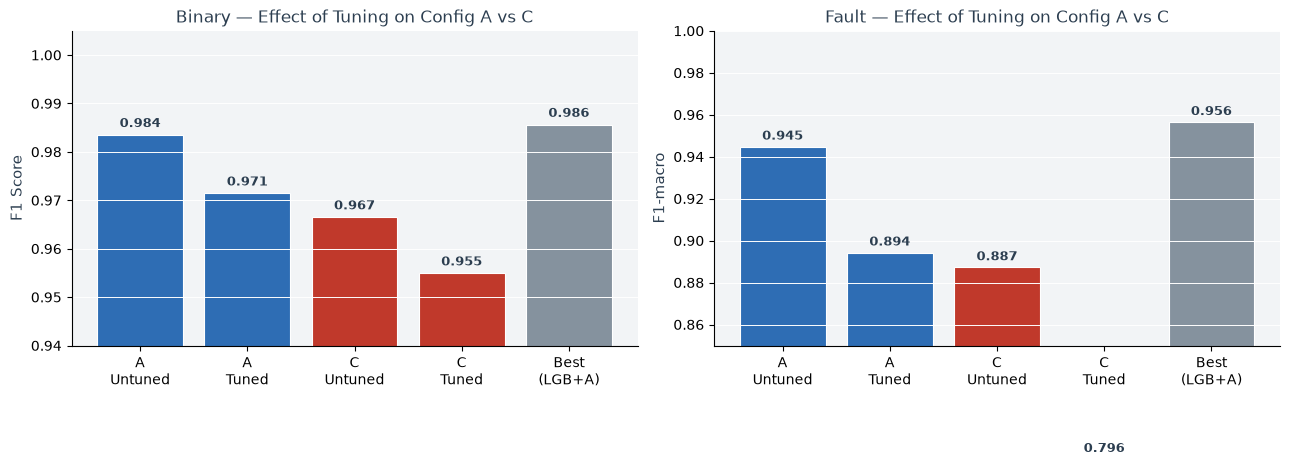

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Binary
methods = ['A\nUntuned', 'A\nTuned', 'C\nUntuned', 'C\nTuned', 'Best\n(LGB+A)']
binary_vals = [
    BASELINE['A_binary_untuned'],
    tuned_A_binary_f1,
    BASELINE['C_binary_untuned'],
    tuned_C_binary_f1,
    BASELINE['best_binary_ever'],
]
colors_bar = [COLORS['normal'], COLORS['normal'],
              COLORS['anomaly'], COLORS['anomaly'], COLORS['synthetic']]

bars = axes[0].bar(methods, binary_vals, color=colors_bar,
                    edgecolor='white', linewidth=0.8)
axes[0].set_ylim(0.94, 1.005)
axes[0].set_ylabel('F1 Score', fontsize=11, color=COLORS['axis'])
axes[0].set_title('Binary — Effect of Tuning on Config A vs C',
                  fontsize=12, color=COLORS['axis'])
axes[0].set_facecolor(COLORS['grid'])
axes[0].grid(axis='y', color='white', linewidth=0.7)
axes[0].spines[['top','right']].set_visible(False)
for bar, val in zip(bars, binary_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9,
                 fontweight='bold', color=COLORS['axis'])

# Fault
fault_vals = [
    BASELINE['A_fault_untuned'],
    tuned_A_mc_f1,
    BASELINE['C_fault_untuned'],
    tuned_C_mc_f1,
    BASELINE['best_fault_ever'],
]
bars2 = axes[1].bar(methods, fault_vals, color=colors_bar,
                     edgecolor='white', linewidth=0.8)
axes[1].set_ylim(0.85, 1.0)
axes[1].set_ylabel('F1-macro', fontsize=11, color=COLORS['axis'])
axes[1].set_title('Fault — Effect of Tuning on Config A vs C',
                  fontsize=12, color=COLORS['axis'])
axes[1].set_facecolor(COLORS['grid'])
axes[1].grid(axis='y', color='white', linewidth=0.7)
axes[1].spines[['top','right']].set_visible(False)
for bar, val in zip(bars2, fault_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9,
                 fontweight='bold', color=COLORS['axis'])

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'tuning_comparison.png'), dpi=150)
plt.show()

## 11. Final Verdict

In [16]:
print('=' * 65)
print('FINAL VERDICT — Did Hyperparameter Tuning Rescue Config C?')
print('=' * 65)
print()
print('Binary Detection:')
if tuned_C_binary_f1 > BASELINE['best_binary_ever']:
    print(f'  YES — Tuned Config C ({tuned_C_binary_f1:.4f}) beats best ever ({BASELINE["best_binary_ever"]:.4f})')
    print('  New optimal configuration: Tuned RF + Config C')
elif tuned_C_binary_f1 > BASELINE['A_binary_untuned']:
    print(f'  PARTIAL — Tuned C ({tuned_C_binary_f1:.4f}) beats A untuned but not best ever')
    print('  Best remains: LightGBM + Config A')
else:
    print(f'  NO — Tuned C ({tuned_C_binary_f1:.4f}) still below A untuned ({BASELINE["A_binary_untuned"]:.4f})')
    print('  Best remains: LightGBM + Config A')

print()
print('Fault Classification:')
if tuned_C_mc_f1 > BASELINE['best_fault_ever']:
    print(f'  YES — Tuned Config C ({tuned_C_mc_f1:.4f}) beats best ever ({BASELINE["best_fault_ever"]:.4f})')
    print('  New optimal configuration: Tuned RF + Config C')
elif tuned_C_mc_f1 > BASELINE['A_fault_untuned']:
    print(f'  PARTIAL — Tuned C ({tuned_C_mc_f1:.4f}) beats A untuned but not best ever')
    print('  Best remains: XGBoost + Config A')
else:
    print(f'  NO — Tuned C ({tuned_C_mc_f1:.4f}) still below A untuned ({BASELINE["A_fault_untuned"]:.4f})')
    print('  Best remains: XGBoost + Config A')

FINAL VERDICT — Did Hyperparameter Tuning Rescue Config C?

Binary Detection:
  NO — Tuned C (0.9549) still below A untuned (0.9835)
  Best remains: LightGBM + Config A

Fault Classification:
  NO — Tuned C (0.7958) still below A untuned (0.9447)
  Best remains: XGBoost + Config A
